# Analysis of Crop Yield: A Practical Application of ANOVA

## Project Overview

This project demonstrates the use of Analysis of Variance (ANOVA) to solve a real-world business problem. We analyze data from an agricultural study to determine which of three different fertilizers produces the highest crop yield. 

The goal is to provide a data-driven recommendation that could help an agricultural company optimize its crop production and profitability.

### Skills Demonstrated:
- Exploratory Data Analysis (EDA)
- Data Visualization (Seaborn, Matplotlib)
- Statistical Hypothesis Testing
- Analysis of Variance (ANOVA)
- Post-Hoc Analysis (Tukey's HSD)

### How This Analysis Applies to Other Industries

ANOVA is a powerful and versatile statistical technique used to compare the means of two or more groups. The same methodology demonstrated here can be applied across various domains:

- **Marketing:** To determine which advertising campaign (Group A, B, or C) results in the highest mean sales.
- **Manufacturing:** To test if different production processes (Group 1, 2, 3) affect the mean strength of a product.
- **Healthcare:** To compare the mean recovery time of patients under different treatment plans.

Understanding ANOVA is a core skill for any data scientist looking to draw meaningful conclusions from experimental data.

## 1. Environment Setup

First, let's ensure all the necessary libraries are installed. The following cell contains the command to install the required packages. If your environment is already set up, you can skip this step. Otherwise, uncomment the line and run the cell.

In [20]:
# !pip install pandas numpy seaborn matplotlib scipy statsmodels

## 2. Data Loading and Initial Exploration

Now, we import the libraries and load our dataset. We'll then perform an initial inspection to understand its structure, data types, and check for any missing values.

In [21]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import f_oneway, shapiro, levene
from statsmodels.stats.multicomp import pairwise_tukeyhsd

# Load the dataset
df = pd.read_csv('field_data.csv')

# Display the first few rows
print("First 5 rows of the dataset:")
display(df.head())

First 5 rows of the dataset:


,height,temp,humidity,fertilizer,yield,region
0,1,70,72,1,397.228692,1
1,2,68,76,1,397.550041,2
2,1,69,63,1,396.408462,3
3,2,69,65,1,397.703625,4
4,1,70,76,1,397.125486,1


In [22]:
# Get a summary of the dataset
print("\nDataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   height      96 non-null     int64  
 1   temp        96 non-null     int64  
 2   humidity    96 non-null     int64  
 3   fertilizer  96 non-null     int64  
 4   yield       96 non-null     float64
 5   region      96 non-null     int64  
dtypes: float64(1), int64(5)
memory usage: 4.6 KB


In [23]:
# Get descriptive statistics for the 'yield' column
print("\nDescriptive Statistics for Crop Yield:")
display(df['yield'].describe())


Descriptive Statistics for Crop Yield:


count     96.000000
mean     397.015476
std        0.664548
min      395.360840
25%      396.468696
50%      397.058105
75%      397.398571
max      399.060899
Name: yield, dtype: float64

## 3. Exploratory Data Analysis (EDA)

In this section, we visualize the data to better understand the relationships between variables. A boxplot is an excellent way to see the distribution of crop yield for each fertilizer type.

/var/folders/gr/6hh63wv56hzbm8kcbf7zw0f80000gn/T/ipykernel_67650/1567317908.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='fertilizer', y='yield', palette='pastel')


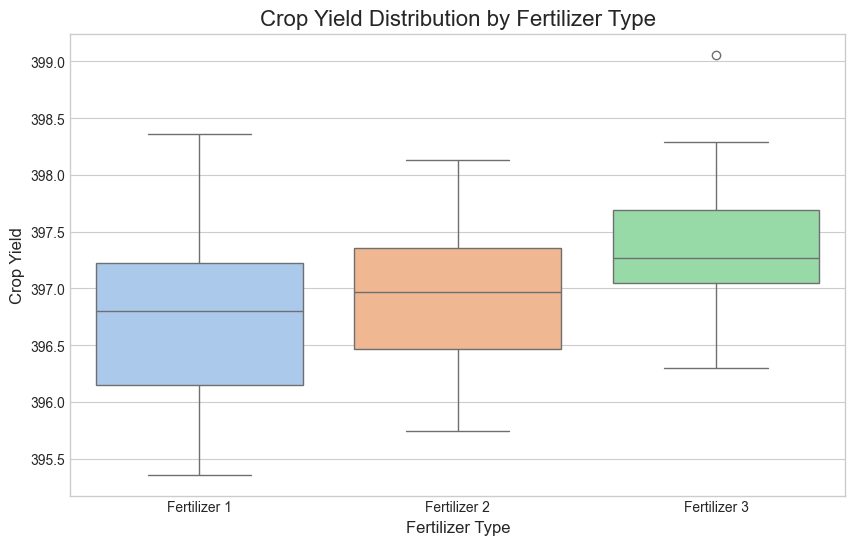

In [24]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x='fertilizer', y='yield', palette='pastel')

plt.title('Crop Yield Distribution by Fertilizer Type', fontsize=16)
plt.xlabel('Fertilizer Type', fontsize=12)
plt.ylabel('Crop Yield', fontsize=12)
plt.xticks(ticks=[0, 1, 2], labels=['Fertilizer 1', 'Fertilizer 2', 'Fertilizer 3'])
plt.show()

**Initial Observation:** The boxplot suggests that there might be a difference in the mean yields. Fertilizer 3 appears to have a slightly higher median yield compared to Fertilizers 1 and 2. We will use ANOVA to statistically test if this difference is significant.

We can also examine the relationships between all numerical variables using a correlation heatmap.

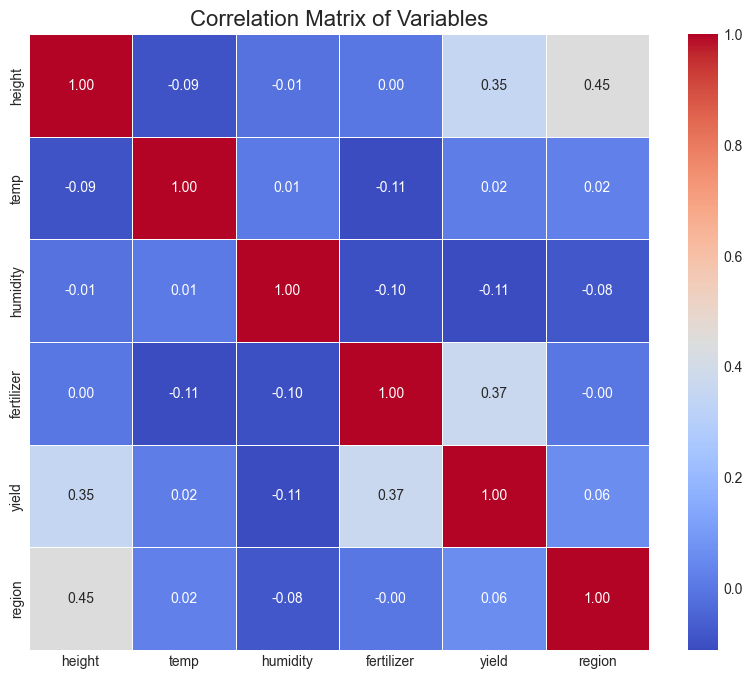

In [25]:
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Variables', fontsize=16)
plt.show()

**Observation:** The heatmap shows very weak correlations between crop yield and other variables like temperature and humidity. The strongest correlation is with `fertilizer`, which is what we will investigate further.

## 4. Statistical Analysis: One-Way ANOVA

One-Way ANOVA is used to determine whether there are any statistically significant differences between the means of two or more independent groups. 

#### Hypotheses
- **Null Hypothesis (H₀):** The mean crop yield is the same for all three fertilizer groups. (μ₁ = μ₂ = μ₃)
- **Alternative Hypothesis (H₁):** At least one fertilizer group has a different mean crop yield.

### Checking ANOVA Assumptions
Before performing ANOVA, we must check three key assumptions:

1.  **Normality:** The data in each group should be approximately normally distributed.
2.  **Homogeneity of Variances (Homoscedasticity):** The variances of the groups should be equal.
3.  **Independence:** The observations are independent of one another.

#### Assumption 1: Normality Test
We use the **Shapiro-Wilk test** to check for normality in each fertilizer group. The null hypothesis for this test is that the data is normally distributed.

In [26]:
fertilizer1_yield = df[df['fertilizer'] == 1]['yield']
fertilizer2_yield = df[df['fertilizer'] == 2]['yield']
fertilizer3_yield = df[df['fertilizer'] == 3]['yield']

stat1, p1 = shapiro(fertilizer1_yield)
stat2, p2 = shapiro(fertilizer2_yield)
stat3, p3 = shapiro(fertilizer3_yield)

print(f"Shapiro-Wilk Test for Fertilizer 1: p-value = {p1:.3f}")
print(f"Shapiro-Wilk Test for Fertilizer 2: p-value = {p2:.3f}")
print(f"Shapiro-Wilk Test for Fertilizer 3: p-value = {p3:.3f}")

# Interpretation
alpha = 0.05
if p1 > alpha and p2 > alpha and p3 > alpha:
    print("\nConclusion: All groups appear to be normally distributed (fail to reject H₀).")
else:
    print("\nConclusion: At least one group does not appear to be normally distributed.")

Shapiro-Wilk Test for Fertilizer 1: p-value = 0.774
Shapiro-Wilk Test for Fertilizer 2: p-value = 0.887
Shapiro-Wilk Test for Fertilizer 3: p-value = 0.254

Conclusion: All groups appear to be normally distributed (fail to reject H₀).


#### Assumption 2: Homogeneity of Variances Test
We use **Levene's test** to check if the variances among the groups are equal. The null hypothesis is that the variances are equal.

In [27]:
stat_levene, p_levene = levene(fertilizer1_yield, fertilizer2_yield, fertilizer3_yield)

print(f"Levene's Test for Homogeneity of Variances: p-value = {p_levene:.3f}")

if p_levene > alpha:
    print("\nConclusion: The variances are equal across groups (fail to reject H₀).")
else:
    print("\nConclusion: The variances are not equal across groups.")

Levene's Test for Homogeneity of Variances: p-value = 0.432

Conclusion: The variances are equal across groups (fail to reject H₀).


**Result:** Since both assumptions are met, we can proceed with the ANOVA test.

### Performing the ANOVA Test

In [28]:
f_statistic, p_value_anova = f_oneway(fertilizer1_yield, fertilizer2_yield, fertilizer3_yield)

print(f"One-Way ANOVA Results:")
print(f"F-Statistic: {f_statistic:.3f}")
print(f"P-value: {p_value_anova:.4f}")

if p_value_anova < alpha:
    print("\nConclusion: We reject the null hypothesis. There is a statistically significant difference in mean crop yield among the fertilizer groups.")
else:
    print("\nConclusion: We fail to reject the null hypothesis. There is no statistically significant difference in mean crop yield.")

One-Way ANOVA Results:
F-Statistic: 7.863
P-value: 0.0007

Conclusion: We reject the null hypothesis. There is a statistically significant difference in mean crop yield among the fertilizer groups.


### Post-Hoc Analysis: Tukey's HSD Test

The ANOVA test told us that there is a significant difference *somewhere* among the groups, but it didn't tell us *which specific groups* are different from each other. 

To find this out, we perform a **Tukey's Honestly Significant Difference (HSD)** post-hoc test. This test compares all possible pairs of groups.

Tukey's HSD Post-Hoc Test:
Multiple Comparison of Means - Tukey HSD, FWER=0.05
group1 group2 meandiff p-adj   lower  upper  reject
---------------------------------------------------
     1      2   0.1762 0.4955 -0.1937 0.5461  False
     1      3   0.5991 0.0006  0.2292  0.969   True
     2      3    0.423 0.0209  0.0531 0.7928   True
---------------------------------------------------


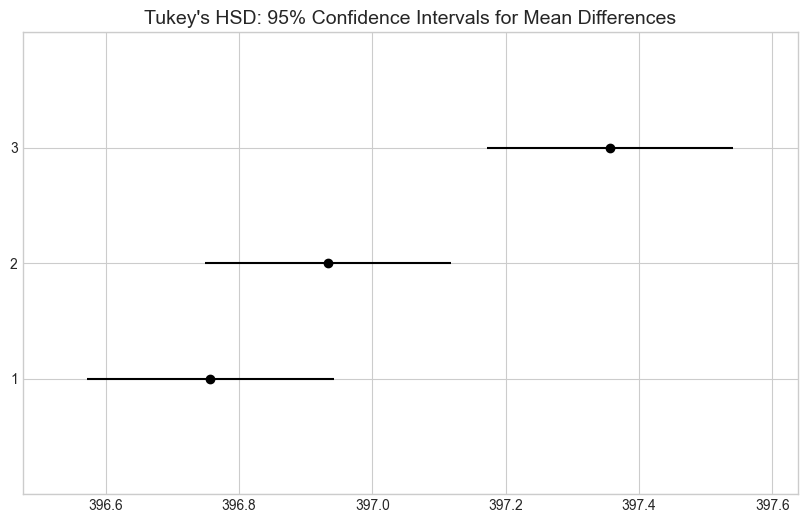

In [29]:
tukey_result = pairwise_tukeyhsd(endog=df['yield'], groups=df['fertilizer'], alpha=alpha)

print("Tukey's HSD Post-Hoc Test:")
print(tukey_result)

# Plot the results
tukey_result.plot_simultaneous()
plt.title("Tukey's HSD: 95% Confidence Intervals for Mean Differences", fontsize=14)
plt.show()

**Interpretation of Tukey's Test:**

The results table shows the difference in means for each pair of fertilizers. The `p-adj` column is the most important one here. If the p-value is less than 0.05, the difference between that pair is statistically significant.

- **Pair (1, 2):** p-value > 0.05. The difference is **not significant**.
- **Pair (1, 3):** p-value < 0.05. The difference is **significant**.
- **Pair (2, 3):** p-value < 0.05. The difference is **significant**.

This tells us that Fertilizer 3 produces a significantly different yield compared to both Fertilizer 1 and Fertilizer 2. The difference between Fertilizer 1 and 2 is not significant.

## 5. Conclusion & Recommendation

Our analysis has provided a clear and statistically significant result.

### Findings:
1.  **Significant Difference:** The one-way ANOVA test confirmed a significant difference in mean crop yield among the three fertilizer groups (p < 0.001).
2.  **Superior Performance:** The Tukey's HSD post-hoc test revealed that **Fertilizer 3** produces a statistically significant higher mean yield compared to both Fertilizer 1 and Fertilizer 2.
3.  **No Difference Between 1 & 2:** There was no significant difference in performance between Fertilizer 1 and Fertilizer 2.

### Recommendation:

**We recommend the use of Fertilizer 3.**

This recommendation is backed by statistical evidence. By switching to Fertilizer 3, the agricultural company can expect to achieve a significantly higher crop yield, leading to increased production and potential for greater revenue.

## 6. References

- **Dataset:** Culler, J. (n.d.). [field_data.csv]. Kaggle. https://www.kaggle.com/datasets/jhonculler/fdffa
- **Reference Text:** Rogel-Salazar, J. (2023). <i>Statistics and data visualisation with python</i>. CRC Press.